# 03 — Text Analysis: TF-IDF + NMF Topic Modeling
**Project:** DustiniaDelixia Groceria — Customer Experience Analysis  
**Hipotesis:** H5 — What complaints are most frequently mentioned in negative reviews?  
**Input:** `data/processed/negative_reviews_text.csv` (score 1–2, ~10,839 reviews)  
**Metode:** TF-IDF (unigram + bigram) → NMF Topic Modeling  
**Bahasa corpus:** Portuguese (Brazilian)

---
**Catatan penting:**
- `lannister` = nama toko fiktif dalam dataset (538 occurrences) → custom stopword
- `nao` = typo dari `não` → normalisasi sebelum tokenisasi
- Analisis score 1 dan score 2 **dipisah** untuk melihat severity keluhan

**Urutan section:**
1. Setup & Konfigurasi
2. Load & Preview Corpus
3. Text Preprocessing
4. TF-IDF Analysis
5. NMF Topic Modeling
6. Cross-Analysis: Topic × Score
7. Insights Summary


## 0. Setup & Konfigurasi

In [86]:
from pathlib import Path
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Path auto-detection
NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = ROOT / 'data' / 'processed'
DOCS           = ROOT / 'docs'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLOR_SCORE1  = '#d62728'
COLOR_SCORE2  = '#ff7f0e'
COLOR_PRIMARY = '#4C72B0'

print('Setup OK.')
print(f'Root: {ROOT}')


Setup OK.
Root: D:\.py\Oprec Admin MCI 2026\dustinia-cx-analysis


## 1. Load & Preview Corpus

Corpus berisi review score 1–2 dengan `review_comment_message` non-null.  
Score 1 dan 2 dianalisis terpisah untuk melihat perbedaan severity keluhan.


In [87]:
neg = pd.read_csv(DATA_PROCESSED / 'negative_reviews_text.csv')

# Filter: buang message sangat pendek (< 15 chars) — terlalu noise
neg = neg[neg['review_comment_message'].str.len() >= 15].copy().reset_index(drop=True)

df_s1 = neg[neg['review_score'] == 1].copy().reset_index(drop=True)
df_s2 = neg[neg['review_score'] == 2].copy().reset_index(drop=True)

print('[Corpus Overview]')
print(f'  Total reviews (>=15 chars) : {len(neg):,}')
print(f'  Score 1 (very negative)    : {len(df_s1):,}  ({len(df_s1)/len(neg)*100:.1f}%)')
print(f'  Score 2 (moderately neg.)  : {len(df_s2):,}  ({len(df_s2)/len(neg)*100:.1f}%)')


[Corpus Overview]
  Total reviews (>=15 chars) : 10,608
  Score 1 (very negative)    : 8,535  (80.5%)
  Score 2 (moderately neg.)  : 2,073  (19.5%)


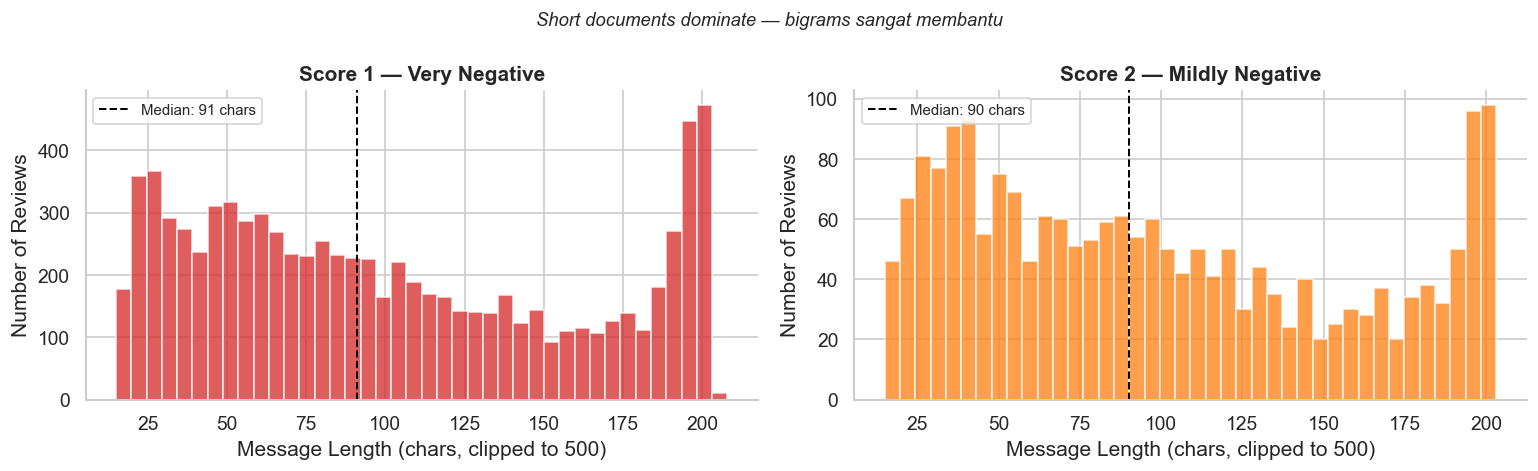

In [88]:
# Message length distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, color, label in [
    (axes[0], df_s1, COLOR_SCORE1, 'Score 1 — Very Negative'),
    (axes[1], df_s2, COLOR_SCORE2, 'Score 2 — Mildly Negative'),
]:
    lens = df['review_comment_message'].str.len().clip(0, 500)
    ax.hist(lens, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(lens.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median: {lens.median():.0f} chars')
    ax.set_xlabel('Message Length (chars, clipped to 500)')
    ax.set_ylabel('Number of Reviews')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Short documents dominate — bigrams sangat membantu',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()


In [89]:
print('[Sample Score 1 reviews]')
for _, row in df_s1.sample(5, random_state=42).iterrows():
    print(f'  -> {row["review_comment_message"][:120]}')

print('\n[Sample Score 2 reviews]')
for _, row in df_s2.sample(5, random_state=42).iterrows():
    print(f'  -> {row["review_comment_message"][:120]}')


[Sample Score 1 reviews]
  -> Não sei se por culpa da transportadora ou não, o fato é de que não recebi o produto ainda, e já está fora do prazo de en
  -> Não é a primeira vez de atraso na entrega, quando consegue falar a atendente ainda pede um prazo de dois dias, fora o at
  -> espaço pequeno para relatar o problema.
  -> Eu comprei o produto, porém o vendedor não tinha o mesmo em estoque. Absurdo! 
  -> Produto entregue errado, reclamação realizada, solicitado de troca aberta a mais de uma semana e nem sinal da empresa

[Sample Score 2 reviews]
  -> Só recebi a capa protetora, o lençol branco não chegou. Além disso a capa protetora não atendeu as minhas expectativas.
  -> Não foi entregue
  -> Recebi o produto ontem. Como se trata de um ventilador de teto comercial e pelo alto preço, imaginei que no mínimo as hé
  -> eu comprei 2luminarias, so que vocês só me mandaram 1 luminária, mandei um email pra vocês falando do meu problema, so q
  -> Não gostei da qualidade do produto. Achei

## 2. Text Preprocessing

### Keputusan preprocessing:
1. **Lowercase** — standar
2. **Normalisasi typo** — `nao` → `não`, `ptoduto` → `produto`
3. **Hapus angka & tanda baca** — tidak ada angka meaningful di level term
4. **Stopwords:** NLTK Portuguese (207 kata) + custom stopwords spesifik dataset
5. **Hapus token pendek** (< 3 karakter)
6. **Tidak pakai stemmer** — readability > presisi linguistik untuk presentasi CEO

### Custom stopwords yang ditambahkan:
- `lannister`, `lanniste` — nama toko fiktif (538 occurrences = noise)
- `nao` — unaccented typo dari 'tidak'
- `pra`, `pois`, `apenas`, `ainda` — filler terlalu generik
- `aguardo`, `aguardando` — kata tunggu tanpa konten keluhan spesifik


In [90]:
PT_STOPS = set(stopwords.words('portuguese'))

CUSTOM_STOPS = {
    # Store name noise
    'lannister', 'lanniste', 'lannist',
    # Unaccented typo after normalization
    'nao',
    # Generic filler words
    'pra', 'pois', 'apenas', 'ainda', 'agora', 'hoje', 'assim',
    'nada', 'quero', 'vou', 'fiz', 'pedi', 'ter',
    # Waiting words without complaint content
    'aguardo', 'aguardando',
}

ALL_STOPS = PT_STOPS | CUSTOM_STOPS

TYPO_MAP = [
    (r'\bnao\b',       'nao_'),     # mark for removal after normalization
    (r'\bptoduto\b',  'produto'),
    (r'\bcorreio\b',  'correios'),
]

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    for pattern, repl in TYPO_MAP:
        text = re.sub(pattern, repl, text)
    # Keep only Portuguese letters + spaces
    text = re.sub(r'[^a-z\u00e0-\u00ff\s]', ' ', text)
    tokens = [t for t in text.split() if len(t) >= 3 and t not in ALL_STOPS]
    return ' '.join(tokens)

neg['cleaned_text']   = neg['review_comment_message'].apply(normalize_text)
df_s1['cleaned_text'] = df_s1['review_comment_message'].apply(normalize_text)
df_s2['cleaned_text'] = df_s2['review_comment_message'].apply(normalize_text)

# Remove empty after cleaning
neg   = neg[neg['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)
df_s1 = df_s1[df_s1['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)
df_s2 = df_s2[df_s2['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)

print('After preprocessing:')
print(f'  Total : {len(neg):,}')
print(f'  Score 1: {len(df_s1):,}  |  Score 2: {len(df_s2):,}')

print('\n[Sample cleaned texts]')
for i in range(3):
    row = df_s1.iloc[i]
    print(f'  ORIGINAL : {row["review_comment_message"][:100]}')
    print(f'  CLEANED  : {row["cleaned_text"][:100]}')
    print()


After preprocessing:
  Total : 10,597
  Score 1: 8,527  |  Score 2: 2,070

[Sample cleaned texts]
  ORIGINAL : O mocho não tem nem 6 meses de uso e a parte da estrutura já está rachando! Produto de péssima quali
  CLEANED  : mocho meses uso parte estrutura rachando produto péssima qualidade

  ORIGINAL : Simplesmente cancelaram a compra a nem tentaram dar uma explicação ou chegar num resultado que fosse
  CLEANED  : simplesmente cancelaram compra tentaram dar explicação chegar resultado satisfatório ambas partes re

  ORIGINAL : Minha opinião é que se comprei o produto ele tinha que ser entregue e não receber um notificação que
  CLEANED  : opinião comprei produto entregue receber notificação dado entregue produto então empresa devolva din



## 3. TF-IDF Analysis

### Parameter TF-IDF:
- `ngram_range=(1,2)` — unigrams + bigrams
- `max_features=5000` — cukup untuk corpus pendek
- `min_df=5` — term minimal di 5 dokumen
- `max_df=0.85` — hapus term terlalu umum
- `sublinear_tf=True` — log normalization


In [91]:
TFIDF_PARAMS = dict(
    ngram_range  = (1, 2),
    max_features = 5000,
    min_df       = 5,
    max_df       = 0.85,
    sublinear_tf = True,
)

# Fit on full corpus
vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_all  = vectorizer.fit_transform(neg['cleaned_text'])
feature_names = vectorizer.get_feature_names_out()

# Score-specific vectorizers (separate fit for fair per-score comparison)
vec_s1   = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_s1 = vec_s1.fit_transform(df_s1['cleaned_text'])
feat_s1  = vec_s1.get_feature_names_out()

vec_s2   = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_s2 = vec_s2.fit_transform(df_s2['cleaned_text'])
feat_s2  = vec_s2.get_feature_names_out()

print(f'TF-IDF (all) : {tfidf_all.shape[0]:,} docs x {tfidf_all.shape[1]:,} features')
print(f'TF-IDF (S1)  : {tfidf_s1.shape[0]:,} docs x {tfidf_s1.shape[1]:,} features')
print(f'TF-IDF (S2)  : {tfidf_s2.shape[0]:,} docs x {tfidf_s2.shape[1]:,} features')


TF-IDF (all) : 10,597 docs x 3,679 features
TF-IDF (S1)  : 8,527 docs x 3,004 features
TF-IDF (S2)  : 2,070 docs x 849 features


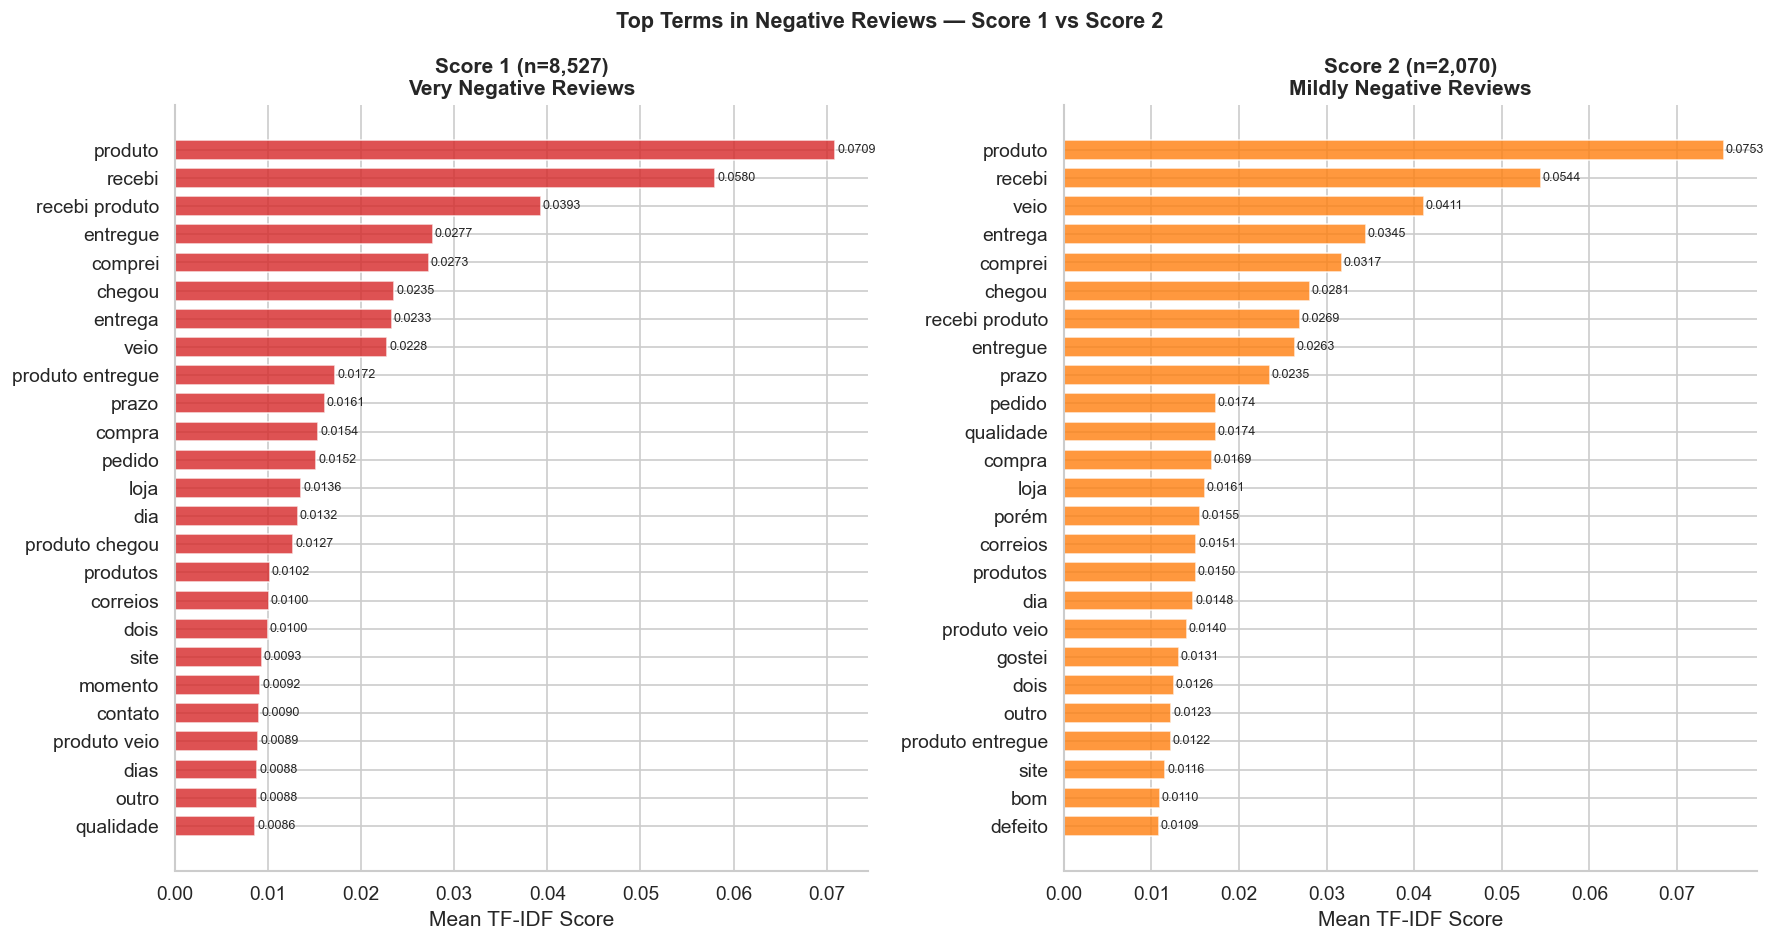


[Score 1]
 1. produto                        (TF-IDF=0.0709)
 2. recebi                         (TF-IDF=0.0580)
 3. recebi produto                 (TF-IDF=0.0393)
 4. entregue                       (TF-IDF=0.0277)
 5. comprei                        (TF-IDF=0.0273)
 6. chegou                         (TF-IDF=0.0235)
 7. entrega                        (TF-IDF=0.0233)
 8. veio                           (TF-IDF=0.0228)
 9. produto entregue               (TF-IDF=0.0172)
10. prazo                          (TF-IDF=0.0161)
11. compra                         (TF-IDF=0.0154)
12. pedido                         (TF-IDF=0.0152)
13. loja                           (TF-IDF=0.0136)
14. dia                            (TF-IDF=0.0132)
15. produto chegou                 (TF-IDF=0.0127)

[Score 2]
 1. produto                        (TF-IDF=0.0753)
 2. recebi                         (TF-IDF=0.0544)
 3. veio                           (TF-IDF=0.0411)
 4. entrega                        (TF-IDF=0.0345)
 5. compr

In [92]:
def get_top_terms(tfidf_matrix, feature_names, top_n=30):
    mean_scores = tfidf_matrix.mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:top_n]
    return [(feature_names[i], mean_scores[i]) for i in top_idx]

top_s1 = get_top_terms(tfidf_s1, feat_s1, 30)
top_s2 = get_top_terms(tfidf_s2, feat_s2, 30)

N = 25
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for ax, top_terms, color, title in [
    (axes[0], top_s1[:N], COLOR_SCORE1, f'Score 1 (n={len(df_s1):,})\nVery Negative Reviews'),
    (axes[1], top_s2[:N], COLOR_SCORE2, f'Score 2 (n={len(df_s2):,})\nMildly Negative Reviews'),
]:
    terms  = [t[0] for t in reversed(top_terms)]
    scores = [t[1] for t in reversed(top_terms)]
    bars   = ax.barh(terms, scores, color=color, alpha=0.80, height=0.7, edgecolor='white')
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(title, fontweight='bold')
    for bar, sc in zip(bars, scores):
        ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                f'{sc:.4f}', va='center', fontsize=7.5)

plt.suptitle('Top Terms in Negative Reviews — Score 1 vs Score 2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for review_score, top_terms in [(1, top_s1), (2, top_s2)]:
    print(f"\n[Score {review_score}]")

    for i, (term, tfidf_score) in enumerate(top_terms[:15], start=1):
        print(
            f"{i:>2}. "
            f"{term:<30} "
            f"(TF-IDF={tfidf_score:.4f})"
        )


In [93]:
# Term divergence analysis
set_s1 = {t[0] for t in top_s1}
set_s2 = {t[0] for t in top_s2}

print('[Term Overlap — Score 1 vs Score 2 Top-30]')
print(f'  Shared     : {len(set_s1 & set_s2)} terms -> {sorted(set_s1 & set_s2)}')
print(f'\n  Only S1    : {len(set_s1 - set_s2)} terms -> {sorted(set_s1 - set_s2)}')
print(f'\n  Only S2    : {len(set_s2 - set_s1)} terms -> {sorted(set_s2 - set_s1)}')
print('\nTerms only in Score 1 = indikasi keluhan BERAT.')
print('Terms only in Score 2 = indikasi ketidakpuasan SEDANG.')


[Term Overlap — Score 1 vs Score 2 Top-30]
  Shared     : 23 terms -> ['chegou', 'compra', 'comprei', 'correios', 'dia', 'dois', 'entrega', 'entregue', 'loja', 'outro', 'pedido', 'prazo', 'produto', 'produto chegou', 'produto entregue', 'produto veio', 'produtos', 'qualidade', 'recebi', 'recebi produto', 'recomendo', 'site', 'veio']

  Only S1    : 7 terms -> ['contato', 'dias', 'dinheiro', 'mercadoria', 'momento', 'paguei', 'resposta']

  Only S2    : 7 terms -> ['achei', 'bom', 'cor', 'defeito', 'diferente', 'gostei', 'porém']

Terms only in Score 1 = indikasi keluhan BERAT.
Terms only in Score 2 = indikasi ketidakpuasan SEDANG.


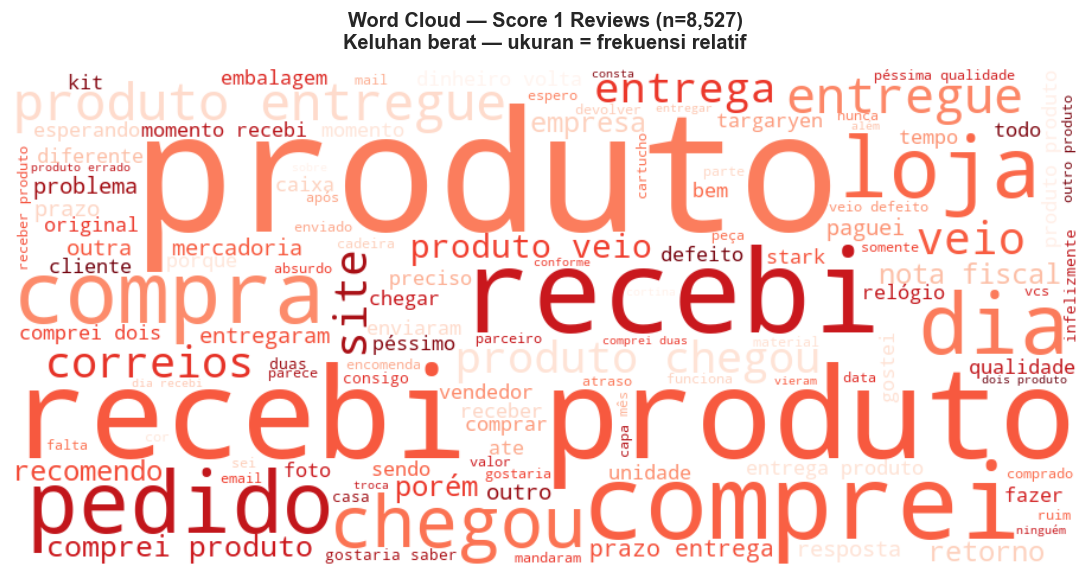

In [94]:
# Wordcloud Score 1
text_s1 = ' '.join(df_s1['cleaned_text'])
wc_s1 = WordCloud(
    width=900, height=420,
    background_color='white',
    colormap='Reds',
    max_words=120,
    min_font_size=9,
    collocations=True,
    stopwords=ALL_STOPS,
).generate(text_s1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(wc_s1, interpolation='bilinear')
ax.axis('off')
ax.set_title(f'Word Cloud — Score 1 Reviews (n={len(df_s1):,})\n'
             'Keluhan berat — ukuran = frekuensi relatif',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


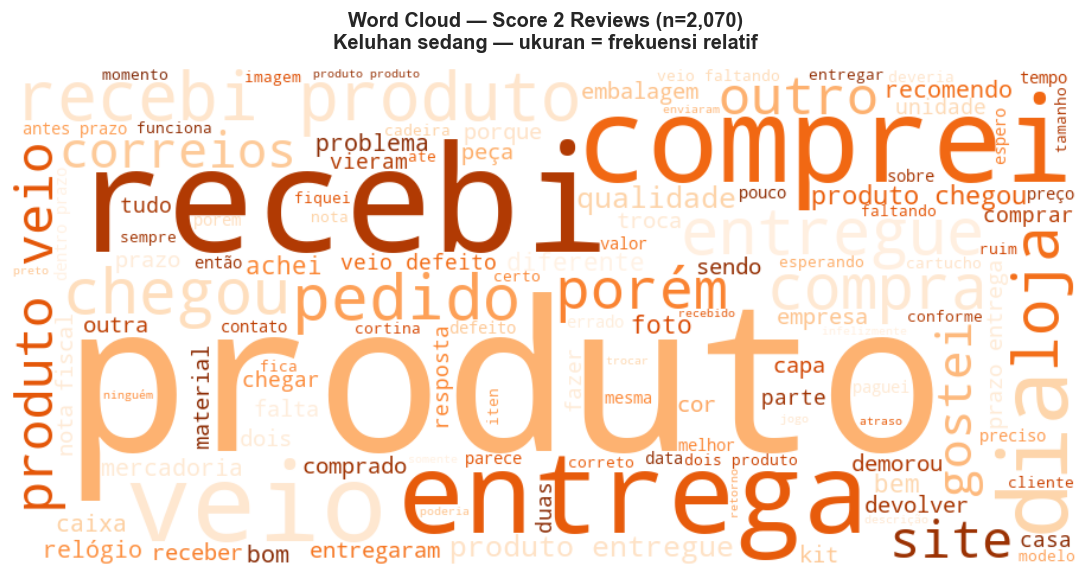

In [95]:
# Wordcloud Score 2
text_s2 = ' '.join(df_s2['cleaned_text'])
wc_s2 = WordCloud(
    width=900, height=420,
    background_color='white',
    colormap='Oranges',
    max_words=120,
    min_font_size=9,
    collocations=True,
    stopwords=ALL_STOPS,
).generate(text_s2)

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(wc_s2, interpolation='bilinear')
ax.axis('off')
ax.set_title(f'Word Cloud — Score 2 Reviews (n={len(df_s2):,})\n'
             'Keluhan sedang — ukuran = frekuensi relatif',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 4. NMF Topic Modeling

### Mengapa NMF, bukan LDA?
- **Dokumen pendek** (median ~89 chars): LDA membutuhkan dokumen panjang
  untuk prior distribusi Dirichlet yang stabil. NMF lebih robust.
- **Non-negative decomposition**: mudah diinterpretasi (tidak ada term negatif).
- **Speed**: lebih cepat untuk iterasi eksplorasi.

### Memilih n_topics:
Plot reconstruction error untuk n=3–10.  
Pilih nilai di 'siku' kurva. Prioritaskan **interpretability** — apakah topic  
bisa diberi label yang meaningful untuk CEO?


Fitting NMF untuk n=3 hingga n=10...
  n=3: err=99.49
  n=4: err=99.03
  n=5: err=98.61
  n=6: err=98.24
  n=7: err=97.93
  n=8: err=97.65
  n=9: err=97.43
  n=10: err=97.18


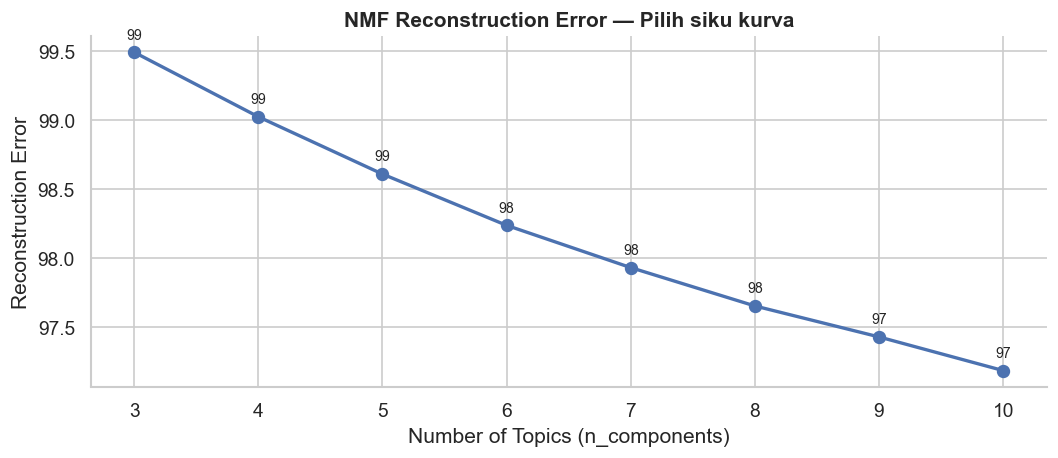

Pilih N_TOPICS di sel berikutnya.


In [96]:
print('Fitting NMF untuk n=3 hingga n=10...')
errors = []
for n in range(3, 11):
    m = NMF(n_components=n, random_state=42, init='nndsvda', max_iter=500)
    m.fit_transform(tfidf_all)
    errors.append(m.reconstruction_err_)
    print(f'  n={n}: err={m.reconstruction_err_:.2f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(3, 11), errors, marker='o', color=COLOR_PRIMARY, linewidth=2, markersize=7)
ax.set_xlabel('Number of Topics (n_components)')
ax.set_ylabel('Reconstruction Error')
ax.set_title('NMF Reconstruction Error — Pilih siku kurva', fontweight='bold')
ax.set_xticks(range(3, 11))
for n, err in zip(range(3, 11), errors):
    ax.annotate(f'{err:.0f}', (n, err), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8.5)
plt.tight_layout()
plt.show()
print('Pilih N_TOPICS di sel berikutnya.')


### Edit `N_TOPICS` di sel berikutnya

**Default: `N_TOPICS = 4`**

Setelah run dan lihat topics, **edit `TOPIC_LABELS`** di sel selanjutnya.


In [97]:
# EDIT N_TOPICS JIKA PERLU
N_TOPICS = 5

nmf_model = NMF(
    n_components = N_TOPICS,
    random_state = 42,
    init         = 'nndsvda',
    max_iter     = 1000,
)
W_all = nmf_model.fit_transform(tfidf_all)
H_all = nmf_model.components_

print(f'NMF fitted: {N_TOPICS} topics')
print(f'  W (docs x topics): {W_all.shape}')
print(f'  H (topics x terms): {H_all.shape}')


NMF fitted: 5 topics
  W (docs x topics): (10597, 5)
  H (topics x terms): (5, 3679)


In [98]:
# Display topics
print('[NMF Topics — Top 12 terms each]')
print('=' * 65)
for i, component in enumerate(nmf_model.components_):
    top_idx   = component.argsort()[::-1][:12]
    top_words = [feature_names[j] for j in top_idx]
    print(f'  Topic {i}: {" | ".join(top_words[:10])}')

print('\nEdit TOPIC_LABELS di sel berikutnya sesuai hasil di atas.')


[NMF Topics — Top 12 terms each]
  Topic 0: recebi produto | recebi | produto | momento recebi | momento | avaliar | produto errado | produto recebi | comprei | paguei
  Topic 1: entregue | produto entregue | produto | momento | entregue produto | entregue prazo | entregue momento | consta | pedido entregue | pedido
  Topic 2: chegou | produto chegou | produto | chegou produto | chegou prazo | quebrado | chegou quebrado | prazo | qualidade | comprei
  Topic 3: entrega | prazo | prazo entrega | dia | entrega produto | demora | demora entrega | compra | passou | dias
  Topic 4: veio | comprei | produto veio | produto | dois | defeito | outro | veio defeito | produtos | errado

Edit TOPIC_LABELS di sel berikutnya sesuai hasil di atas.


### Edit Label Topics

Lihat top terms di output di atas, lalu edit `TOPIC_LABELS` di sel berikutnya.  
Label ini digunakan di semua visualisasi, summary, dan Metabase.

Berdasarkan output n=5 yang sudah kamu share sebelumnya, ini mapping yang paling defensible:

| Topic | Top terms | Label yang direkomendasikan | Tema H5 yang divalidasi |
|---|---|---|---|
| T0 | `recebi`, `produto errado`, `paguei` | `Wrong / Incomplete Item` | Produk Tidak Sesuai Deskripsi |
| T1 | `entregue`, `entregue prazo`, `consta` | `Order Not Delivered` | Pengiriman Tidak Sampai / Hilang |
| T2 | `chegou`, `chegou quebrado`, `qualidade` | `Product Arrival Issues` | Produk Rusak / Belum Sampai |
| T3 | `entrega`, `prazo`, `demora`, `dias` | `Delivery Delay` | Keterlambatan Pengiriman |
| T4 | `veio`, `veio defeito`, `dois`, `errado` | `Defective / Wrong Item` | Produk Tidak Sesuai + Produk Rusak |

In [99]:
# EDIT LABELS SESUAI HASIL NMF DI ATAS
TOPIC_LABELS = {
    0: 'Wrong / Incomplete Item',
    1: 'Order Not Delivered',
    2: 'Product Arrival Issues',
    3: 'Delivery Delay',
    4: 'Defective / Wrong Item',
}

assert len(TOPIC_LABELS) == N_TOPICS, f'Labels {len(TOPIC_LABELS)} != N_TOPICS {N_TOPICS}'
print('Topic labels set:')
for k, v in TOPIC_LABELS.items():
    print(f'  Topic {k}: {v}')


Topic labels set:
  Topic 0: Wrong / Incomplete Item
  Topic 1: Order Not Delivered
  Topic 2: Product Arrival Issues
  Topic 3: Delivery Delay
  Topic 4: Defective / Wrong Item


In [100]:
# Dominant topic per review
dominant_topic = W_all.argmax(axis=1)

topic_counts = (
    pd.Series(dominant_topic)
    .value_counts()
    .sort_index()
    .rename_axis('topic_id')
    .reset_index(name='review_count')
)

topic_counts['topic_label'] = topic_counts['topic_id'].map(TOPIC_LABELS)
topic_counts['pct_reviews'] = (
    topic_counts['review_count'] / topic_counts['review_count'].sum()* 100)

topic_counts = topic_counts[
    ['topic_id', 'topic_label', 'review_count', 'pct_reviews']
].sort_values('review_count', ascending=False).reset_index(drop=True)
topic_counts.index = range(1, len(topic_counts) + 1)

print('[Topic Size Distribution]')
display(topic_counts)

print(
    f'\nLargest topic: '
    f'{topic_counts.iloc[0]["topic_label"]} '
    f'({topic_counts.iloc[0]["pct_reviews"]:.1f}%)'
)

[Topic Size Distribution]


,topic_id,topic_label,review_count,pct_reviews
1,4,Defective / Wrong Item,4805,45.343022
2,3,Delivery Delay,1994,18.816646
3,0,Wrong / Incomplete Item,1581,14.919317
4,2,Product Arrival Issues,1281,12.088327
5,1,Order Not Delivered,936,8.832688



Largest topic: Defective / Wrong Item (45.3%)


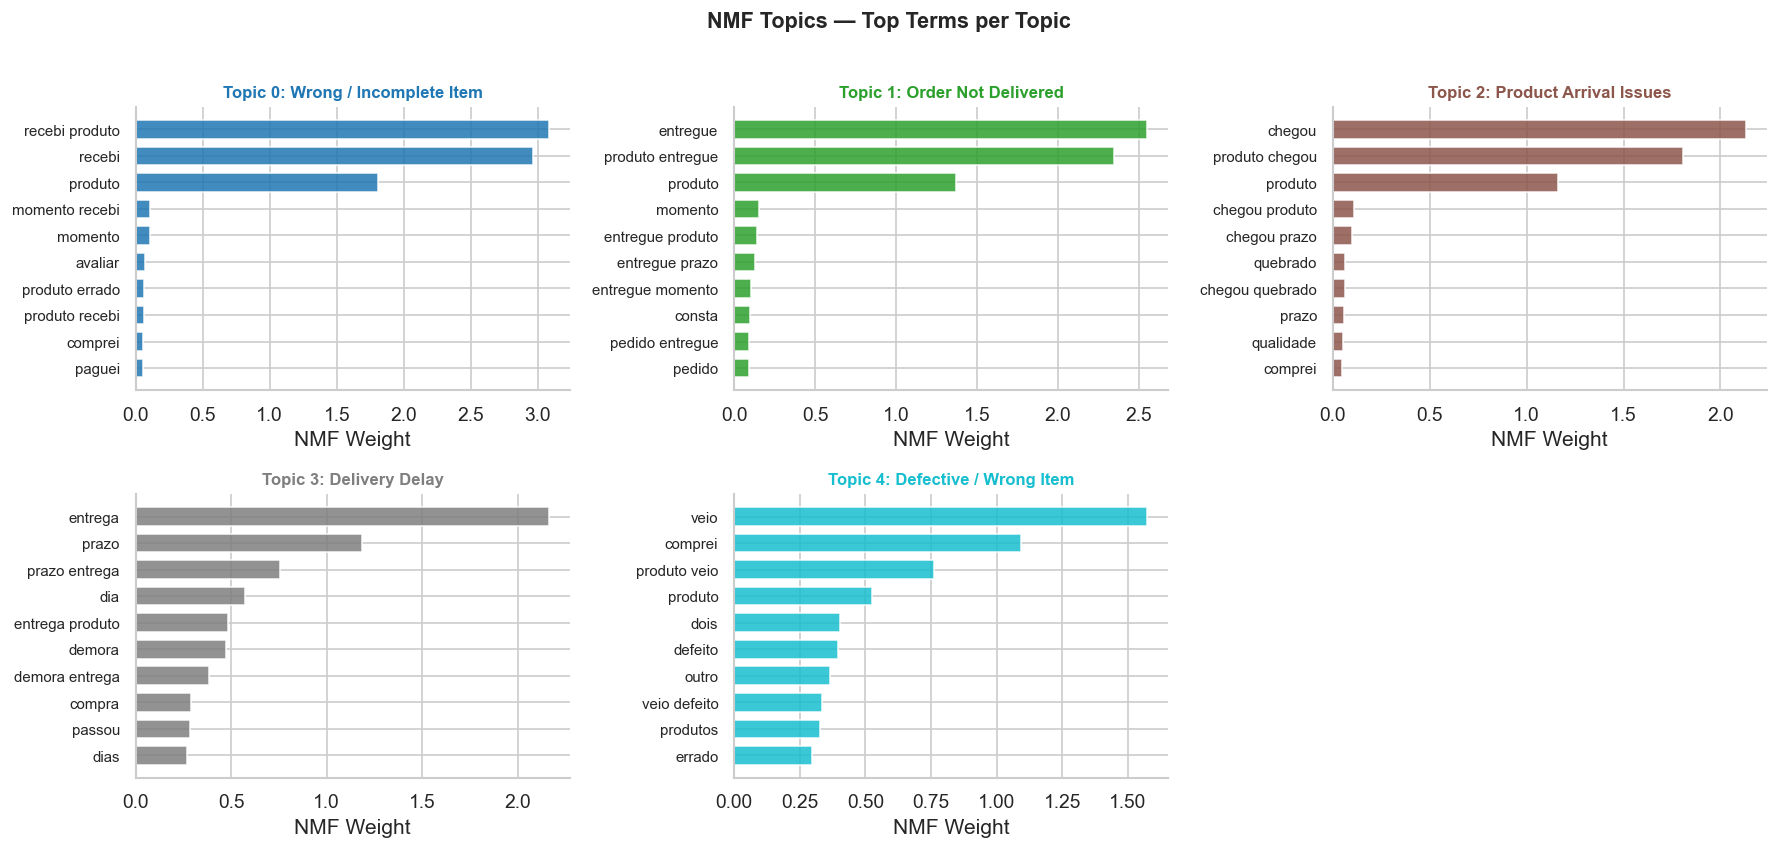

In [101]:
# Topic bar chart grid
n_cols = 3
n_rows = (N_TOPICS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes_flat = axes.flatten()
cmap = plt.colormaps()[N_TOPICS % len(plt.colormaps())] if N_TOPICS == 1 else plt.get_cmap('tab10', N_TOPICS)

for i, (component, ax) in enumerate(zip(nmf_model.components_, axes_flat)):
    top_idx     = component.argsort()[::-1][:10]
    top_words   = [feature_names[j] for j in reversed(top_idx)]
    top_weights = [component[j]     for j in reversed(top_idx)]
    ax.barh(top_words, top_weights, color=cmap(i), alpha=0.85, height=0.7, edgecolor='white')
    ax.set_title(f'Topic {i}: {TOPIC_LABELS[i]}', fontweight='bold', color=cmap(i), fontsize=10)
    ax.set_xlabel('NMF Weight')
    ax.tick_params(axis='y', labelsize=9)

for j in range(N_TOPICS, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('NMF Topics — Top Terms per Topic', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [102]:
# Representative reviews per topic
neg['dominant_topic']   = W_all.argmax(axis=1)
neg['topic_confidence'] = W_all.max(axis=1)

print('[Representative Reviews per Topic]')
print('=' * 70)
for topic_id in range(N_TOPICS):
    topic_data = neg[neg['dominant_topic'] == topic_id]
    count = len(topic_data)
    pct   = count / len(neg) * 100
    top3  = topic_data.nlargest(3, 'topic_confidence')
    print(f'\nTopic {topic_id}: {TOPIC_LABELS[topic_id]}  (n={count:,}, {pct:.1f}%)')
    print('-' * 60)
    for _, row in top3.iterrows():
        print(f'  [S{int(row["review_score"])}] {row["review_comment_message"][:140]}')


[Representative Reviews per Topic]

Topic 0: Wrong / Incomplete Item  (n=1,581, 14.9%)
------------------------------------------------------------
  [S1] Ainda não recebi o produto. 
  [S1] Eu não recebi o produto.
  [S1] Eu não recebi meu produto


Topic 1: Order Not Delivered  (n=936, 8.8%)
------------------------------------------------------------
  [S1] Meu produto não foi entregue e está constatado como entregue...

  [S1] O produto ainda não foi entregue.
  [S1] Produto não foi entregue

Topic 2: Product Arrival Issues  (n=1,281, 12.1%)
------------------------------------------------------------
  [S1] O produto não chegou
  [S1] O produto ainda não chegou.
  [S1] MEU PRODUTO AINDA NÃO CHEGOU!!!!

Topic 3: Delivery Delay  (n=1,994, 18.8%)
------------------------------------------------------------
  [S1] Ainda esta no prazo para entrega
  [S1] O prazo da entrega nao foi comprido.
  [S1] Não respeitou o prazo da entrega

Topic 4: Defective / Wrong Item  (n=4,805, 45.3%)
-----

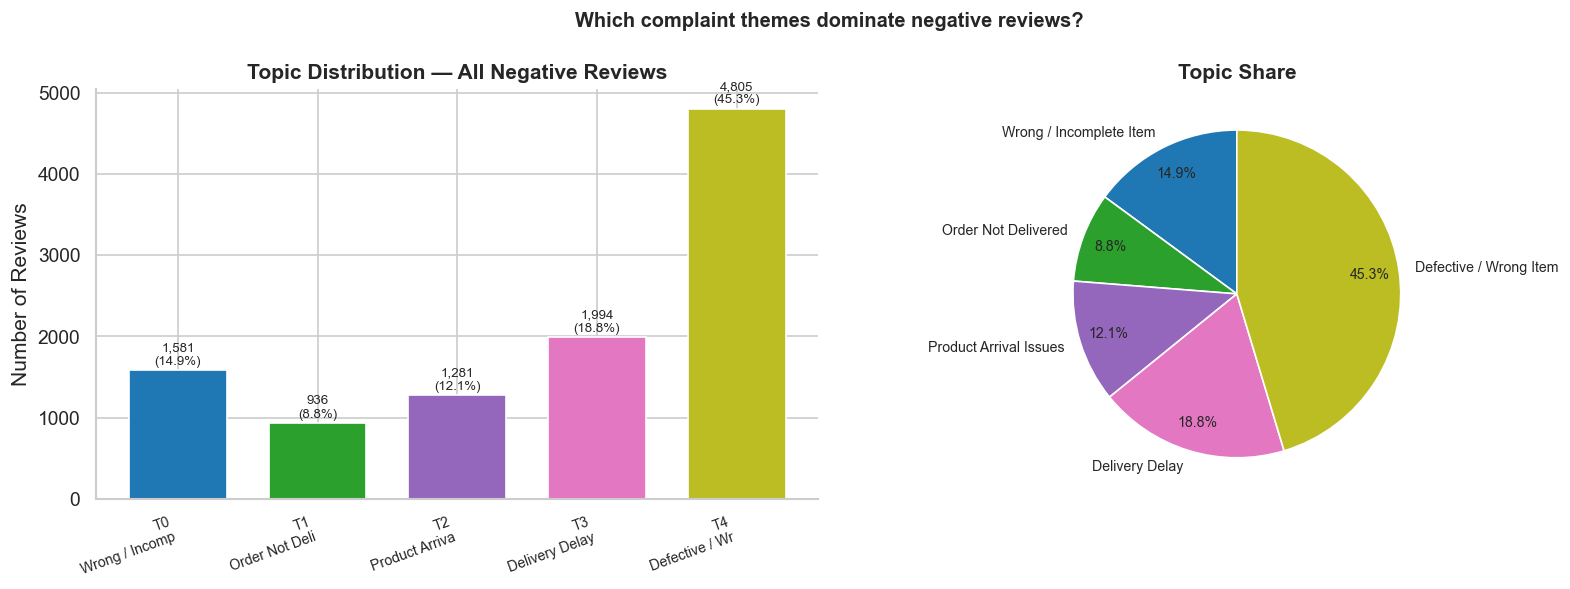

In [103]:
# Topic distribution chart
topic_counts = neg['dominant_topic'].value_counts().sort_index()
colors = [plt.cm.tab10(i / N_TOPICS) for i in topic_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(range(N_TOPICS), topic_counts.values, color=colors, edgecolor='white', width=0.7)
ax1.set_xticks(range(N_TOPICS))
ax1.set_xticklabels(
    [f'T{i}\n{TOPIC_LABELS[i][:14]}' for i in range(N_TOPICS)],
    fontsize=8.5, rotation=20, ha='right'
)
ax1.set_ylabel('Number of Reviews')
ax1.set_title('Topic Distribution — All Negative Reviews', fontweight='bold')
for bar, count in zip(bars, topic_counts.values):
    pct = count / topic_counts.sum() * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

ax2.pie(topic_counts.values,
        labels=[TOPIC_LABELS[i] for i in topic_counts.index],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 8.5}, pctdistance=0.82)
ax2.set_title('Topic Share', fontweight='bold')

plt.suptitle('Which complaint themes dominate negative reviews?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Cross-Analysis: Topic x Score

**Pertanyaan:** Apakah topic distribusi berbeda antara score 1 dan score 2?  
Topic yang lebih dominan di score 1 adalah **keluhan berat** yang paling merusak experience.


In [104]:
# Cross-tab: % per score
cross_pct = pd.crosstab(
    neg['review_score'], neg['dominant_topic'], normalize='index'
) * 100
cross_pct.columns = [TOPIC_LABELS[c] for c in cross_pct.columns]
cross_pct.index   = [f'Score {i}' for i in cross_pct.index]

display(cross_pct.style
    .format('{:.1f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
    .set_caption('Topic Distribution by Score (% within each score)')
)


,Wrong / Incomplete Item,Order Not Delivered,Product Arrival Issues,Delivery Delay,Defective / Wrong Item
Score 1,16.1%,9.4%,12.0%,18.4%,44.1%
Score 2,10.0%,6.5%,12.5%,20.6%,50.5%


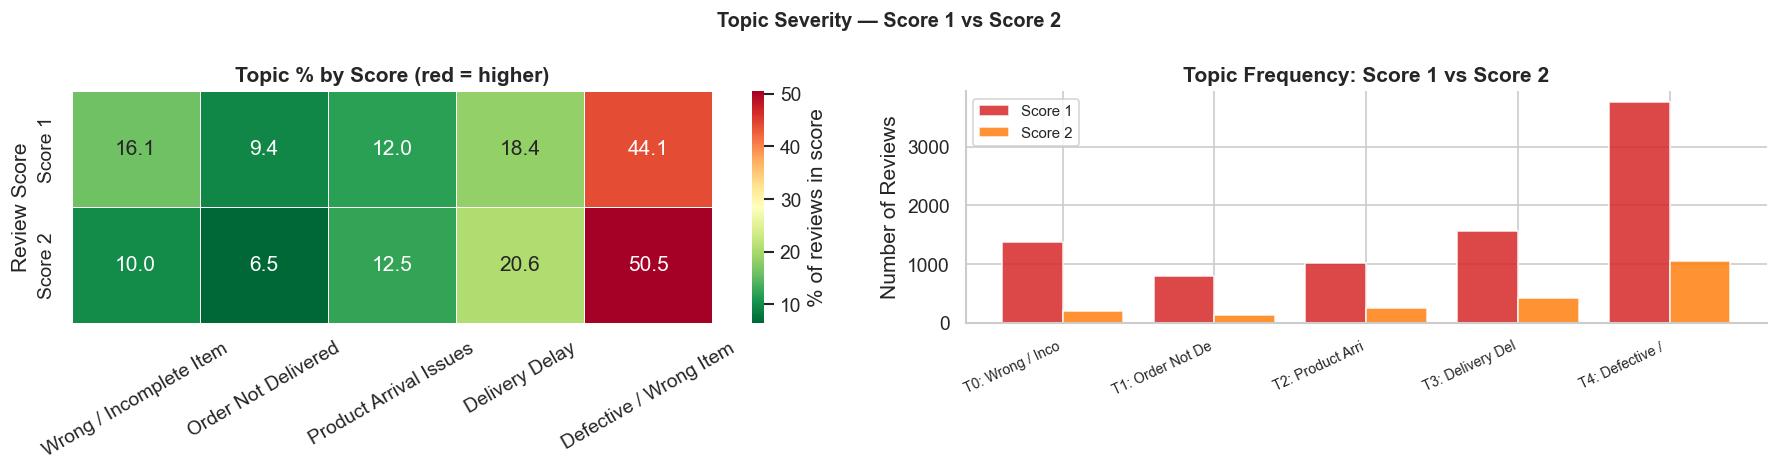

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Heatmap
sns.heatmap(
    cross_pct, annot=True, fmt='.1f',
    cmap='RdYlGn_r', linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': '% of reviews in score'},
)
axes[0].set_title('Topic % by Score (red = higher)', fontweight='bold')
axes[0].set_ylabel('Review Score')
axes[0].tick_params(axis='x', rotation=30)

# Grouped bar
cross_abs = pd.crosstab(neg['review_score'], neg['dominant_topic'])
x = np.arange(N_TOPICS)
w = 0.4
s1_vals = cross_abs.loc[1].values if 1 in cross_abs.index else np.zeros(N_TOPICS)
s2_vals = cross_abs.loc[2].values if 2 in cross_abs.index else np.zeros(N_TOPICS)

axes[1].bar(x - w/2, s1_vals, w, label='Score 1', color=COLOR_SCORE1, alpha=0.85, edgecolor='white')
axes[1].bar(x + w/2, s2_vals, w, label='Score 2', color=COLOR_SCORE2, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f'T{i}: {TOPIC_LABELS[i][:12]}' for i in range(N_TOPICS)],
    rotation=25, ha='right', fontsize=8.5
)
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Topic Frequency: Score 1 vs Score 2', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Topic Severity — Score 1 vs Score 2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [106]:
# Severity ratio
s1_counts = neg[neg['review_score']==1]['dominant_topic'].value_counts().sort_index()
s2_counts = neg[neg['review_score']==2]['dominant_topic'].value_counts().sort_index()
s1_total  = (neg['review_score']==1).sum()
s2_total  = (neg['review_score']==2).sum()

sev_rows = []
for t in range(N_TOPICS):
    s1p = s1_counts.get(t, 0) / s1_total * 100
    s2p = s2_counts.get(t, 0) / s2_total * 100
    ratio = s1p / s2p if s2p > 0 else float('inf')
    sev_rows.append({
        'Topic'      : f'T{t}: {TOPIC_LABELS[t]}',
        'Score1 %'   : round(s1p, 1),
        'Score2 %'   : round(s2p, 1),
        'S1/S2 Ratio': round(ratio, 2),
        'Verdict'    : 'HIGH SEVERITY' if ratio > 1.2 else ('MEDIUM' if ratio > 0.8 else 'MILD'),
    })

sev_df = pd.DataFrame(sev_rows).sort_values('S1/S2 Ratio', ascending=False)
display(sev_df.style
    .format({'Score1 %': '{:.1f}%', 'Score2 %': '{:.1f}%', 'S1/S2 Ratio': '{:.2f}'})
    .set_caption('Topic Severity Ranking — S1/S2 Ratio > 1.2 = High Severity')
    .hide(axis='index')
)


Topic,Score1 %,Score2 %,S1/S2 Ratio,Verdict
T0: Wrong / Incomplete Item,16.1%,10.0%,1.62,HIGH SEVERITY
T1: Order Not Delivered,9.4%,6.5%,1.44,HIGH SEVERITY
T2: Product Arrival Issues,12.0%,12.5%,0.96,MEDIUM
T3: Delivery Delay,18.4%,20.6%,0.89,MEDIUM
T4: Defective / Wrong Item,44.1%,50.5%,0.87,MEDIUM


## 6. Insights Summary & Output

Konsolidasi semua temuan H5 untuk slide, paper IEEE, dan Metabase.


In [107]:
print('[H5 FINAL SUMMARY]')
print('=' * 70)
for topic_id in range(N_TOPICS):
    comp       = nmf_model.components_[topic_id]
    top_idx    = comp.argsort()[::-1][:8]
    top_words  = [feature_names[j] for j in top_idx]
    topic_data = neg[neg['dominant_topic'] == topic_id]
    count      = len(topic_data)
    pct        = count / len(neg) * 100
    s1_share   = (topic_data['review_score']==1).mean() * 100
    rep        = topic_data.nlargest(1, 'topic_confidence')['review_comment_message'].values
    rep_text   = rep[0][:120] if len(rep) > 0 else '-'
    print(f'\nTopic {topic_id}: {TOPIC_LABELS[topic_id]}')
    print(f'  N={count:,} ({pct:.1f}%)  |  {s1_share:.1f}% are score 1')
    print(f'  Terms: {" | ".join(top_words)}')
    print(f'  Example: {rep_text}')

# Save topic assignments
out_df = neg[['order_id','review_score','dominant_topic','topic_confidence']].copy()
out_df['topic_label'] = out_df['dominant_topic'].map(TOPIC_LABELS)
out_df.to_csv(DATA_PROCESSED / 'review_topics.csv', index=False)
print(f'Saved: review_topics.csv -> {len(out_df):,} rows')

# Final summary table
sum_rows = []
for t in range(N_TOPICS):
    comp   = nmf_model.components_[t]
    top_kw = ', '.join([feature_names[j] for j in comp.argsort()[::-1][:5]])
    tdata  = neg[neg['dominant_topic']==t]
    sum_rows.append({
        'Topic'          : TOPIC_LABELS[t],
        'N Reviews'      : len(tdata),
        '% of Negatives' : round(len(tdata)/len(neg)*100, 1),
        '% Score 1'      : round((tdata['review_score']==1).mean()*100, 1),
        'Top Keywords'   : top_kw,
    })

sum_df = pd.DataFrame(sum_rows).sort_values('N Reviews', ascending=False)
display(sum_df.style
    .format({'N Reviews':'{:,}','% of Negatives':'{:.1f}%','% Score 1':'{:.1f}%'})
    .bar(subset=['N Reviews'], color='#AED6F1')
    .bar(subset=['% Score 1'], color='#F1948A', vmax=100)
    .set_caption('H5 Final Summary — Complaint Themes')
    .hide(axis='index')
)

[H5 FINAL SUMMARY]

Topic 0: Wrong / Incomplete Item
  N=1,581 (14.9%)  |  87.0% are score 1
  Terms: recebi produto | recebi | produto | momento recebi | momento | avaliar | produto errado | produto recebi
  Example: Ainda não recebi o produto. 

Topic 1: Order Not Delivered
  N=936 (8.8%)  |  85.6% are score 1
  Terms: entregue | produto entregue | produto | momento | entregue produto | entregue prazo | entregue momento | consta
  Example: Meu produto não foi entregue e está constatado como entregue...


Topic 2: Product Arrival Issues
  N=1,281 (12.1%)  |  79.9% are score 1
  Terms: chegou | produto chegou | produto | chegou produto | chegou prazo | quebrado | chegou quebrado | prazo
  Example: O produto não chegou

Topic 3: Delivery Delay
  N=1,994 (18.8%)  |  78.6% are score 1
  Terms: entrega | prazo | prazo entrega | dia | entrega produto | demora | demora entrega | compra
  Example: Ainda esta no prazo para entrega

Topic 4: Defective / Wrong Item
  N=4,805 (45.3%)  |  78.3% ar

Topic,N Reviews,% of Negatives,% Score 1,Top Keywords
Defective / Wrong Item,"4,805",45.3%,78.3%,"veio, comprei, produto veio, produto, dois"
Delivery Delay,"1,994",18.8%,78.6%,"entrega, prazo, prazo entrega, dia, entrega produto"
Wrong / Incomplete Item,"1,581",14.9%,87.0%,"recebi produto, recebi, produto, momento recebi, momento"
Product Arrival Issues,"1,281",12.1%,79.9%,"chegou, produto chegou, produto, chegou produto, chegou prazo"
Order Not Delivered,936,8.8%,85.6%,"entregue, produto entregue, produto, momento, entregue produto"
